In [1]:
#Imports and Load Data
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))    
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.preprocessor import preprocess_data

# Preprocess (runs loader + cleaning)
df = preprocess_data('data/raw/cafecritic.csv')

Missing values before cleaning:
 index             0
name              0
overall_rating    0
cuisine           0
rate_for_two      0
city              0
review            0
dtype: int64
Preprocessing complete! Missing values after:
 index             0
name              0
overall_rating    0
cuisine           0
rate_for_two      0
city              0
review            0
cleaned_review    0
dtype: int64


In [2]:
#Basic Statistics
print("Dataset Shape:", df.shape)
print("Unique Cafes:", df['name'].nunique())
print("Unique Cities:", df['city'].nunique())
print("Rating Distribution:\n", df['overall_rating'].describe())
# Sparsity (if treating as user-item): Approx if assuming index as users
num_users = df['index'].nunique()  # Proxy
num_items = df['name'].nunique()
sparsity = 1 - (len(df) / (num_users * num_items))
print(f"Sparsity: {sparsity:.2%} (high sparsity typical for recommenders)")

Dataset Shape: (474, 8)
Unique Cafes: 180
Unique Cities: 9
Rating Distribution:
 count    474.000000
mean       3.720886
std        0.430603
min        2.500000
25%        3.400000
50%        3.800000
75%        4.000000
max        4.900000
Name: overall_rating, dtype: float64
Sparsity: 99.44% (high sparsity typical for recommenders)


In [3]:
#Visualizations - Save to results/figures
os.makedirs('results/figures', exist_ok=True)

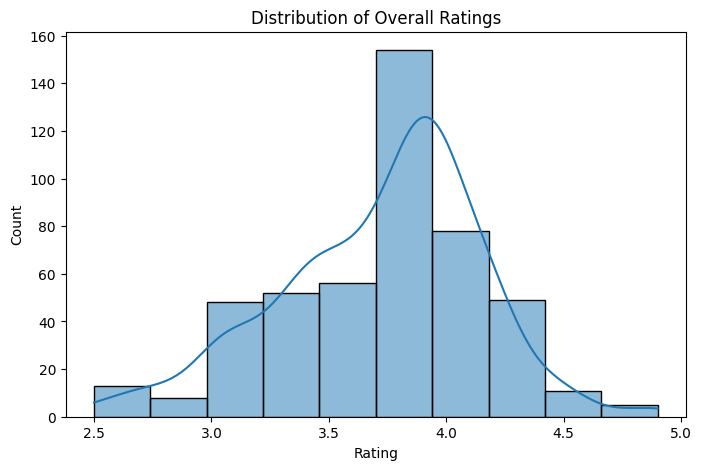

In [4]:
# Rating Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['overall_rating'], bins=10, kde=True)
plt.title('Distribution of Overall Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.savefig('results/figures/rating_distribution.png')
plt.show()

C:\Users\intel\AppData\Local\Temp\ipykernel_21912\3936208106.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.values, y=city_counts.index, palette='viridis')


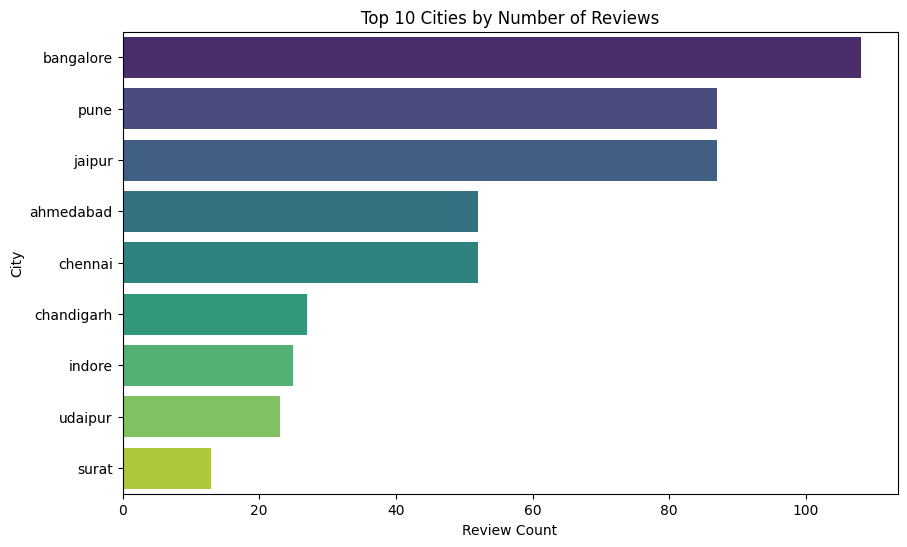

In [5]:
# Top Cities by Review Count
city_counts = df['city'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=city_counts.values, y=city_counts.index, palette='viridis')
plt.title('Top 10 Cities by Number of Reviews')
plt.xlabel('Review Count')
plt.ylabel('City')
plt.savefig('results/figures/top_cities.png')
plt.show()

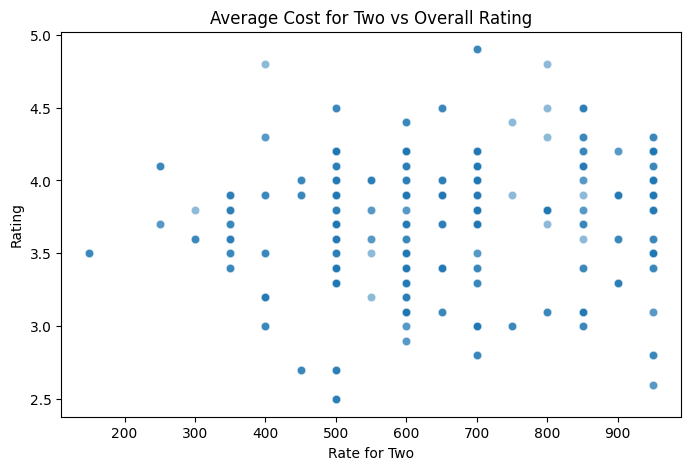

In [6]:
# Cost vs Rating Scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(x='rate_for_two', y='overall_rating', data=df, alpha=0.5)
plt.title('Average Cost for Two vs Overall Rating')
plt.xlabel('Rate for Two')
plt.ylabel('Rating')
plt.savefig('results/figures/cost_vs_rating.png')
plt.show()

C:\Users\intel\AppData\Local\Temp\ipykernel_21912\3634320139.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_counts.values, y=cuisine_counts.index, palette='viridis')


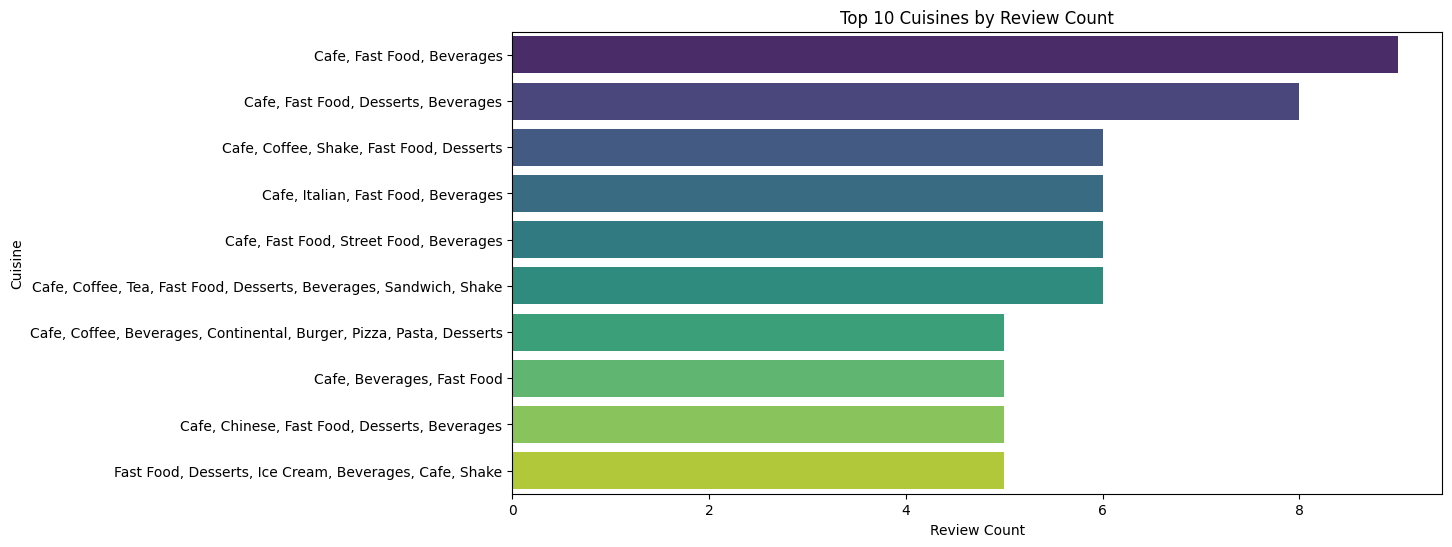

In [7]:
# Cuisine Distribution
plt.figure(figsize=(12, 6))
cuisine_counts = df['cuisine'].value_counts().head(10)  # Top 10 cuisines
sns.barplot(x=cuisine_counts.values, y=cuisine_counts.index, palette='viridis')
plt.title('Top 10 Cuisines by Review Count')
plt.xlabel('Review Count')
plt.ylabel('Cuisine')
plt.savefig('results/figures/top_cuisines.png')
plt.show()

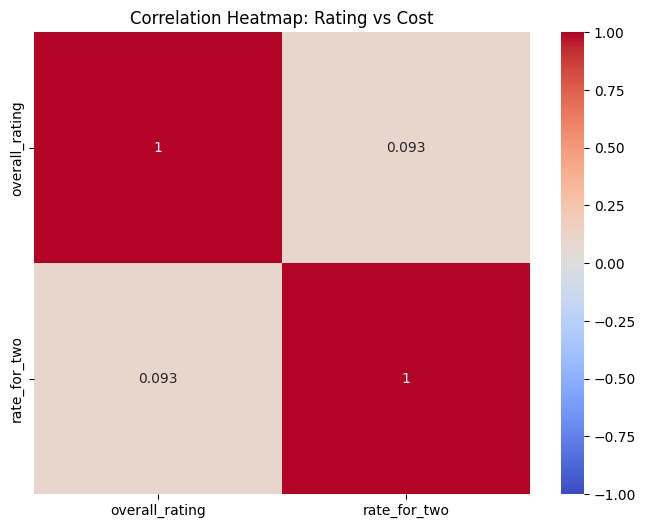

EDA complete! Figures saved to results/figures/


In [8]:
# Correlation Heatmap (Numeric Columns)
plt.figure(figsize=(8, 6))
numeric_df = df[['overall_rating', 'rate_for_two']].dropna()
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Rating vs Cost')
plt.savefig('results/figures/correlation_heatmap.png')
plt.show()

print("EDA complete! Figures saved to results/figures/")